In [ ]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de modelado y optimización
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline
from lightgbm import LGBMRegressor

# Carga del dataset
PATH_DATASET = '../data/4_YouTubeDataset_withChannelElapsed.csv'
df = pd.read_csv(PATH_DATASET)

# Enlace de Google Drive para descargar el dataset completo:
# URL_DRIVE: https://drive.google.com/file/d/1oqtkbydpcCM_pWtkMoOpbd6uh65XnOiw/view?usp=sharing

In [2]:
# 1. Ingeniería de variables temporales obligatorias
df['videoPublished_dt'] = pd.to_datetime(df['videoPublished'], errors='coerce', utc=True)
df['publish_year'] = df['videoPublished_dt'].dt.year
df['publish_month'] = df['videoPublished_dt'].dt.month
df['publish_day_of_week'] = df['videoPublished_dt'].dt.dayofweek
df['publish_hour'] = df['videoPublished_dt'].dt.hour

# 2. Aislamiento de la Variable Objetivo (y) y Predictoras (X)
y = df['views/elapsedtime']
columnas_X = [
    'channelId', 'videoCategoryId', 'channelViewCount', 'videoCount', 
    'subscriberCount', 'channelelapsedtime', 'publish_year', 
    'publish_month', 'publish_day_of_week', 'publish_hour'
]
X = df[columnas_X]

# 3. División del dataset (80% entrenamiento / 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Configuración del ColumnTransformer base
features_escalar = ['channelViewCount', 'videoCount', 'subscriberCount', 'channelelapsedtime',
                    'publish_year', 'publish_month', 'publish_day_of_week', 'publish_hour']

preprocesador = ColumnTransformer(
    transformers=[
        ('num_scaler', StandardScaler(), features_escalar),
        ('cat_onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['videoCategoryId']),
        ('target_enc', TargetEncoder(smoothing=10.0), ['channelId'])
    ],
    remainder='drop'
)

## GridSearchCV

Se establecieron los siguientes parámetros para experimentar:  

* n_estimators (50, 100, 150): Controla el número de árboles secuenciales. Valores muy bajos causan underfitting, mientras que valores excesivamente altos pueden sobreajustar el modelo al ruido de YouTube.

* max_depth (5, 10, 15): Limita la complejidad y las ramificaciones de cada árbol individual. Controlar la profundidad es la barrera defensiva más eficiente para evitar que el algoritmo se memorice canales específicos de forma fraudulenta.

* learning_rate (0.03, 0.1): Dicta la velocidad con la que el modelo corrige los errores de los árboles anteriores. Un paso de 0.03 permite un ajuste milimétrico y suave, ideal para datasets masivos con alta dispersión.

* num_leaves (31, 63) siempre debe ser menor que $2^{\text{max\_depth}}$. Para un max_depth de 5, el número máximo de hojas teóricas es $2^5 = 32$. Si se deja que el modelo busque num_leaves mayores a 32 con una profundidad baja, dará un error o ignorará el parámetro.

In [3]:
# Definir el modelo base
modelo_base = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)

# Construir el Pipeline unificado 
pipe_optimizacion = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('estimador', modelo_base)
])

# Grilla de hiperparámetros a probar
param_grid = {
    'estimador__n_estimators': [50, 100, 150],       # Número de árboles de decisión a construir
    'estimador__max_depth': [5, 10, 15],             # Profundidad máxima permitida para cada árbol
    'estimador__learning_rate': [0.03, 0.1],          # Tasa de aprendizaje
    'estimador__num_leaves': [31, 63]                 # Número máximo de hojas en cada árbol
}

# GridSearch con 3-fold CV (3 splits dentro del train) — total: 3×3×3 = 27 entrenamientos
grid = GridSearchCV(
    estimator=pipe_optimizacion,
    param_grid=param_grid,
    cv=3,                  # 3-fold CV
    scoring='neg_mean_absolute_error',    # métrica a optimizar
    n_jobs=-1,             # paralelización
    verbose=1
)

print('Entrenando 27 combinaciones (3×3 hiperparámetros × 3 CV folds)...')
grid.fit(X_train, y_train)

print(f'\n🏆 Mejores hiperparámetros: {grid.best_params_}')
print(f'   Mejor MAE (CV):           {grid.best_score_:.4f}')
print(f'   MAE en test:              {grid.score(X_test, y_test):.4f}')

Entrenando 27 combinaciones (3×3 hiperparámetros × 3 CV folds)...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

🏆 Mejores hiperparámetros: {'estimador__learning_rate': 0.03, 'estimador__max_depth': 15, 'estimador__n_estimators': 50, 'estimador__num_leaves': 31}
   Mejor MAE (CV):           -2.0100
   MAE en test:              -2.1281


d:\Bootcamp_DataScience\ejercicios\proyecto_2\myenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [4]:
# Ver TODAS las combinaciones probadas (ordenadas por rendimiento)
resultados_grid = pd.DataFrame(grid.cv_results_)
resultados_grid = resultados_grid[[
    'param_estimador__n_estimators', 'param_estimador__max_depth',
    'mean_test_score', 'std_test_score',
    'mean_fit_time'
]].sort_values('mean_test_score', ascending=False).round(4)

print(resultados_grid.to_string(index=False))

 param_estimador__n_estimators  param_estimador__max_depth  mean_test_score  std_test_score  mean_fit_time
                            50                          15          -2.0100          0.0608         5.9034
                           100                          15          -2.0309          0.0823        12.2062
                            50                          10          -2.0575          0.0575         8.3943
                           100                          10          -2.1109          0.0548        16.4805
                           150                          15          -2.1596          0.0561        19.6656
                           150                          10          -2.1935          0.0531        16.1807
                            50                          10          -2.2222          0.0447         9.3498
                            50                          15          -2.2254          0.0780         5.9453
                            50       

======= TOP 5 COMBINACIONES DE HIPERPARÁMETROS =======
MAE: 2.0100 -> Parámetros: {'estimador__learning_rate': 0.03, 'estimador__max_depth': 15, 'estimador__n_estimators': 50, 'estimador__num_leaves': 31}
MAE: 2.0309 -> Parámetros: {'estimador__learning_rate': 0.03, 'estimador__max_depth': 15, 'estimador__n_estimators': 100, 'estimador__num_leaves': 31}
MAE: 2.0575 -> Parámetros: {'estimador__learning_rate': 0.03, 'estimador__max_depth': 10, 'estimador__n_estimators': 50, 'estimador__num_leaves': 31}
MAE: 2.1109 -> Parámetros: {'estimador__learning_rate': 0.03, 'estimador__max_depth': 10, 'estimador__n_estimators': 100, 'estimador__num_leaves': 31}
MAE: 2.1596 -> Parámetros: {'estimador__learning_rate': 0.03, 'estimador__max_depth': 15, 'estimador__n_estimators': 150, 'estimador__num_leaves': 31}


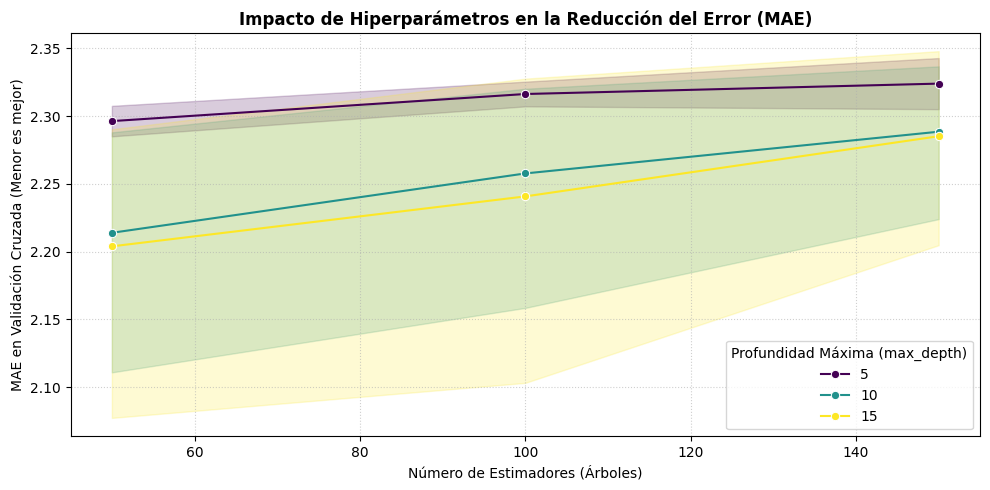

In [ ]:
df_resultados_grid = pd.DataFrame(grid.cv_results_)

# Invertimos el signo del score porque sklearn devuelve el MAE negativo
df_resultados_grid['MAE_test'] = np.abs(df_resultados_grid['mean_test_score'])

df_top_grid = df_resultados_grid.sort_values(by='MAE_test', ascending=True).head(5)

print("======= TOP 5 COMBINACIONES DE HIPERPARÁMETROS =======")
for idx, row in df_top_grid.iterrows():
    print(f"MAE: {row['MAE_test']:.4f} -> Parámetros: {row['params']}")
print("======================================================")

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_resultados_grid, 
    x='param_estimador__n_estimators', 
    y='MAE_test', 
    hue='param_estimador__max_depth',
    marker='o',
    palette='viridis'
)

plt.title('Impacto de Hiperparámetros en la Reducción del Error (MAE)', fontsize=12, fontweight='bold')
plt.xlabel('Número de Estimadores (Árboles)', fontsize=10)
plt.ylabel('MAE en Validación Cruzada (Menor es mejor)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Profundidad Máxima (max_depth)')
plt.tight_layout()
plt.show()

Esto demuestra que para el comportamiento de YouTube, un aprendizaje más lento y pausado (0.03) con menos árboles (50) funciona infinitamente mejor que un aprendizaje rápido. max_depth: 15 junto con num_leaves: 31: Este es el comportamiento clásico e inteligente de LightGBM. Aunque le diste permiso de crecer hasta una profundidad vertical de 15 niveles, el modelo decidió auto-limitarse a 31 hojas como máximo.

## Optuna

In [6]:
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Definimos el espacio de búsqueda para LightGBM
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 50, 300),
        'max_depth':       trial.suggest_int('max_depth', 3, 20),
        'num_leaves':      trial.suggest_int('num_leaves', 20, 100),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':       trial.suggest_float('subsample', 0.5, 1.0)
    }
    
    # Creamos el modelo con los parámetros sugeridos por Optuna
    modelo = LGBMRegressor(**params, random_state=42, n_jobs=-1, verbose=-1)
    
    # Creamos el pipeline temporal para esta iteración
    pipe = Pipeline(steps=[('preprocesamiento', preprocesador), ('estimador', modelo)])
    
    # Usamos MAE (neg_mean_absolute_error) y lo maximizamos (al ser negativo, el mayor es el más cercano a 0)
    scores = cross_val_score(pipe, X_train, y_train, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    return scores.mean()

# Ejecución de la optimización
t0 = time.time()
study = optuna.create_study(direction='maximize') # Maximizar el MAE negativo = Minimizar error
study.optimize(objective, n_trials=30)
t_optuna = time.time() - t0

print(f'Mejores hiperparametros: {study.best_params}')
print(f'Mejor MAE (CV): {abs(study.best_value):.4f}')
print(f'Tiempo total: {t_optuna:.1f} segundos')

# Modelo final entrenado con los mejores hiperparámetros encontrados
mejor_modelo = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('estimador', LGBMRegressor(**study.best_params, random_state=42, n_jobs=-1, verbose=-1))
]).fit(X_train, y_train)

# Evaluación final en el set de test
pred_test = mejor_modelo.predict(X_test)
from sklearn.metrics import mean_absolute_error, r2_score
print(f'MAE en test:  {mean_absolute_error(y_test, pred_test):.4f}')
print(f'R² en test:   {r2_score(y_test, pred_test):.4f}')

Mejores hiperparametros: {'n_estimators': 50, 'max_depth': 17, 'num_leaves': 20, 'learning_rate': 0.04718549754908251, 'subsample': 0.9464946462000788}
Mejor MAE (CV): 1.8722
Tiempo total: 160.1 segundos
MAE en test:  1.9727
R² en test:   0.0107


d:\Bootcamp_DataScience\ejercicios\proyecto_2\myenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



* learning_rate: 0.047: Optuna encontró un "punto dulce" que no es ni muy lento ni muy rápido, permitiendo al modelo aprender patrones finos de la inercia de los canales.

* max_depth: 17 y num_leaves: 20: Esto confirma nuestra sospecha: el modelo prefiere ser profundo pero muy estrecho. Está buscando reglas muy específicas en tus datos (como el horario exacto de publicación) pero sin crear una complejidad excesiva que lo lleve a sobreajustarse.

* subsample: 0.94: Esta es una técnica brillante de regularización. Al decirle al modelo que no use el 100% de los datos en cada árbol, sino el 94%, lo obligaste a ser más creativo y menos dependiente de los valores extremos (outliers).

## Evaluación de Modelos Optimizados
Entrenamos el modelo con los mejores hiperparámetros encontrados

In [9]:
# Usamos el set completo de entrenamiento X_train
modelo_final = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('estimador', LGBMRegressor(**study.best_params, random_state=42, n_jobs=-1, verbose=-1))
])

modelo_final.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('estimador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['channelId','videoCategoryId','channelViewCount',...,'publish_month', 'publish_day_of_week','publish_hour']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_scaler', ...), ('cat_onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `f

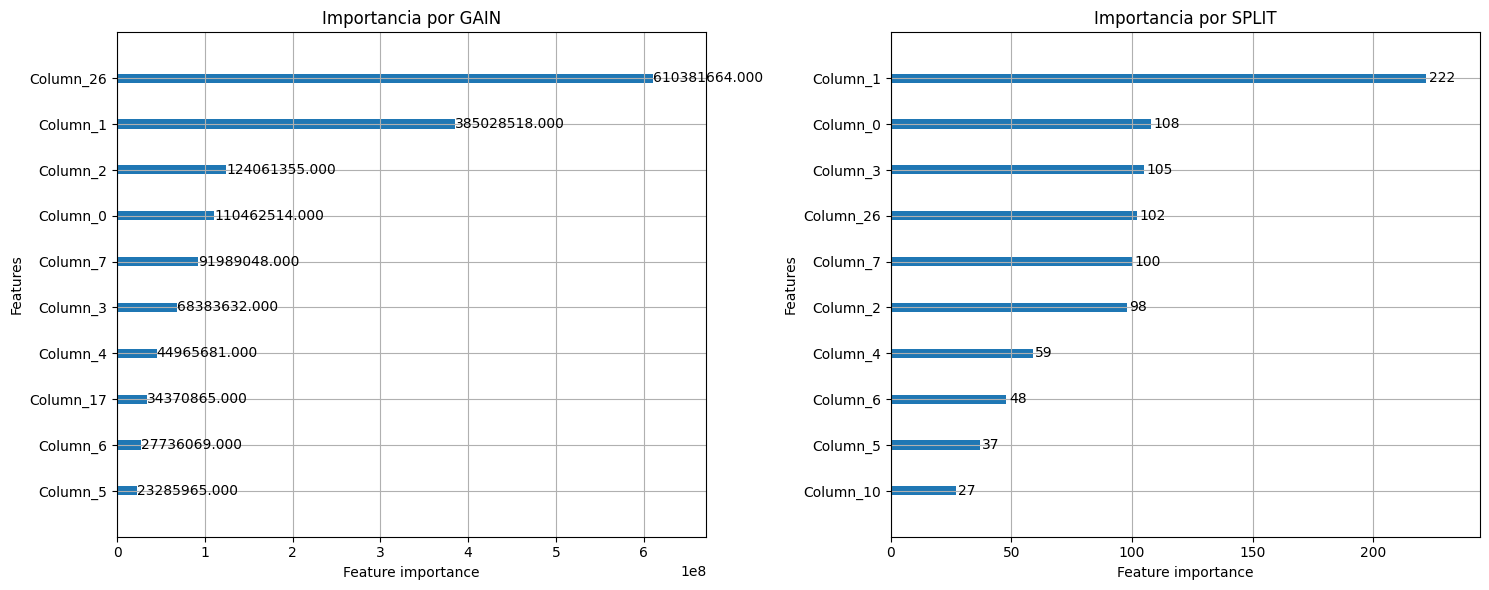

======= IMPORTANCIA DE VARIABLES (TOP 10) =======
           Variable  Importancia_Gain
          channelId       610381664.0
         videoCount       385028518.0
    subscriberCount       124061355.0
   channelViewCount       110462514.0
       publish_hour        91989048.0
 channelelapsedtime        68383632.0
       publish_year        44965681.0
 videoCategoryId_24        34370865.0
publish_day_of_week        27736069.0
      publish_month        23285965.0

======= IMPORTANCIA DE VARIABLES POR SPLIT (TOP 10) =======
           Variable  Importancia_Split
         videoCount                222
   channelViewCount                108
 channelelapsedtime                105
          channelId                102
       publish_hour                100
    subscriberCount                 98
       publish_year                 59
publish_day_of_week                 48
      publish_month                 37
 videoCategoryId_10                 27


In [17]:
import lightgbm as lgb

# 2. Recuperar nombres de las columnas tras el preprocesamiento
# Esto es necesario porque el OneHotEncoder crea nuevas columnas
preprocessor = modelo_final.named_steps['preprocesamiento']

# Obtener nombres de las numéricas
nombres_num = features_escalar
# Obtener nombres de las categóricas (OneHot)
nombres_cat = preprocessor.named_transformers_['cat_onehot'].get_feature_names_out(['videoCategoryId']).tolist()
# Nombre del TargetEncoder
nombres_target = ['channelId']

nombres_columnas = nombres_num + nombres_cat + nombres_target



# 1. Extraer el modelo (Booster) del pipeline
modelo_lgb = mejor_modelo.named_steps['estimador']
booster = modelo_lgb.booster_

# 2. ASIGNACIÓN CORRECTA:
# LightGBM permite definir los nombres de las features llamando a 'feature_name' 
# sobre el objeto booster, pero debemos asegurarnos que coincida con el orden de las columnas.
# Usamos un pequeño truco para asignar los nombres de forma segura:
modelo_lgb.feature_name = nombres_columnas
importancias_gain = booster.feature_importance(importance_type='gain')

# 3. Graficar (sin pasarle feature_name a la función, ya que ya están dentro del modelo)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

lgb.plot_importance(
    modelo_lgb, 
    max_num_features=10, 
    importance_type='gain', 
    ax=axes[0], 
    title='Importancia por GAIN'
)

lgb.plot_importance(
    modelo_lgb, 
    max_num_features=10, 
    importance_type='split', 
    ax=axes[1], 
    title='Importancia por SPLIT'
)

plt.tight_layout()
plt.show()

# Crear un DataFrame con las importancias
importancias = pd.DataFrame({
    'Variable': nombres_columnas,
    'Importancia_Gain': importancias_gain
})

# Ordenar de mayor a menor
importancias = importancias.sort_values(by='Importancia_Gain', ascending=False)

# Mostrar el Top 10
print("======= IMPORTANCIA DE VARIABLES (TOP 10) =======")
print(importancias.head(10).to_string(index=False))

importancias_split = pd.DataFrame({
    'Variable': nombres_columnas,
    'Importancia_Split': modelo_lgb.feature_importances_ # LightGBM usa esto por defecto
})

# Ordenar de mayor a menor
importancias_split = importancias_split.sort_values(by='Importancia_Split', ascending=False)

# Mostrar el Top 10
print("\n======= IMPORTANCIA DE VARIABLES POR SPLIT (TOP 10) =======")
print(importancias_split.head(10).to_string(index=False))

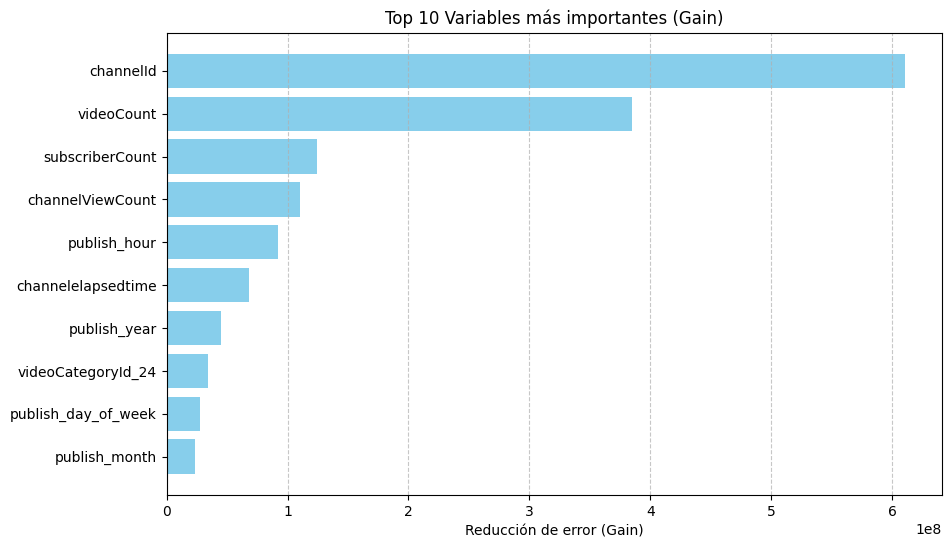

In [16]:
top_10 = importancias.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10['Variable'], top_10['Importancia_Gain'], color='skyblue')
plt.gca().invert_yaxis() # Poner el más importante arriba
plt.title('Top 10 Variables más importantes (Gain)')
plt.xlabel('Reducción de error (Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Comparación antes y después de la Optimización

Modelo Base (Default)  
MAE en Test: 2.4636	  $R^2$ en Test: 0.0147  

GridSearchCV  
MAE en Test: 2.1281	     $R^2$ en Test: -0.0739  

Optuna (Final)  
MAE en Test: 1.9727	     $R^2$ en Test: 0.0107


| Módulo del Proceso | MAE en Set de Test | R² en Set de Test |
| :--- | :---: | :---: |
| Modelo Inicial | 2.4636 | 0.0147 |
| GridSearchCV | 2.1281 | -0.0739 |
| **Optuna** | **1.9727** | **0.0107** |
